# Tutorial 15: Compare RouteCGR Route Sets

This tutorial compares two retrosynthetic route sets through ordered RouteCGR objects. The comparison keeps transient bonds and `route_order` metadata in the RouteCGR hash, then separates routes that are shared between both route sets from routes unique to either set.

The main workflow is: plan or load routes, compose RouteCGRs, compare them with `compare_route_cgr_dicts`, inspect overlapping routes, and cluster the unique routes through reduced SB-CGRs.


In [1]:
from pathlib import Path
from synplan.utils.loading import download_preset

# Download preset data (or use already downloaded)
paths = download_preset("synplanner-gps", save_to="synplan_data")

# input data
ranking_policy_network = paths["ranking_policy"]
reaction_rules_path = paths["reaction_rules"]
building_blocks_path = paths["building_blocks"]

# output folder (shared with other tutorials)
results_folder = Path("tutorial_results").resolve()
results_folder.mkdir(exist_ok=True)

## 2. Retrosynthetic planning
Run a short example to produce routes, or skip if you already have `routes_*.json/csv`.

In [2]:
from synplan.chem.utils import mol_from_smiles

example_smiles = "N#CC1(c2ccc(NC(=O)c3cccnc3NCc3ccncc3)cc2)CCCC1"

target_molecule = mol_from_smiles(
    example_smiles, 
    clean2d=True, 
    standardize=True, 
    clean_stereo=True
    )

In [3]:
target_molecule

# Run example planning
## max_depth=9 for first and max_depth=6 for second

In [4]:
from synplan.mcts.tree import Tree
from synplan.utils.config import TreeConfig, RolloutEvaluationConfig
from synplan.utils.loading import load_building_blocks, load_reaction_rules, load_policy_function, load_evaluation_function
from synplan.routes.quality.scorer import ProtectionRouteScorer

building_blocks = load_building_blocks(building_blocks_path, standardize=False)
reaction_rules = load_reaction_rules(reaction_rules_path)

policy_network = load_policy_function(weights_path=ranking_policy_network)

tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=300,
    max_time=120,
    max_depth=9,
    min_mol_size=1,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
)

eval_config = RolloutEvaluationConfig(
    policy_network=policy_network,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    min_mol_size=tree_config.min_mol_size,
    max_depth=tree_config.max_depth,
    normalize=True,
)
evaluation_function = load_evaluation_function(eval_config)

# Protection-aware route scorer (uses bundled SMARTS and incompatibility matrix)
route_scorer = ProtectionRouteScorer.from_config()

tree_1 = Tree(
    target=target_molecule,
    config=tree_config,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_network,
    evaluation_function=evaluation_function,
    route_scorer=route_scorer,
)

for solved, node_id in tree_1:
    pass
tree_1

  0%|          | 0/300 [00:00<?, ?it/s]

Tree for: C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
Time: 11.6 seconds
Number of nodes: 3623
Number of iterations: 300
Number of visited nodes: 292
Number of found routes: 761

In [5]:
tree_config_2 = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=300,
    max_time=120,
    max_depth=6,
    min_mol_size=1,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
)

tree_2 = Tree(
    target=target_molecule,
    config=tree_config_2,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_network,
    evaluation_function=evaluation_function,
    route_scorer=route_scorer,
)

for solved, node_id in tree_2:
    pass
tree_2

  0%|          | 0/300 [00:00<?, ?it/s]

Tree for: C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
Time: 10.1 seconds
Number of nodes: 3385
Number of iterations: 300
Number of visited nodes: 293
Number of found routes: 772

In [6]:
from synplan.routes.route_cgr import (
    compose_all_route_cgrs,
    compose_all_sb_cgrs,
)
from synplan.routes.route_cgr.hash import (
    compare_route_cgr_dicts,
    route_order_variant_sets,
)
from synplan.routes.clustering.core import (
    cluster_routes,
    routes_clustering_report,

)
from synplan.routes.analysis import (
    compare_sb_cgr_clusters,
    flatten_route_id_groups,
    route_cgr_overlap_rows,
    route_cgr_subset,
)
from synplan.routes.notebook_plots import plot_sb_cgr_cluster_venn
from IPython.display import display, SVG, HTML
from synplan.utils.visualisation import get_route_svg


Module map: `depiction.py` handles CGR/SVG rendering; `notebook_plots.py` contains notebook-only analysis plots; `route_cgr_container.py` owns the `RouteCGRContainer` subclass.


## RouteCGR Composition

`compose_all_route_cgrs` converts each route into one RouteCGR object. Use `preserve_transient_bonds=True` when comparing routes, because bonds that form and later break during the route are part of the route history and participate in the RouteCGR hash.


In [7]:
all_route_cgrs_1 = compose_all_route_cgrs(tree_1)
all_route_cgrs_2 = compose_all_route_cgrs(tree_2)

## Hash-Based Route Set Comparison

`compare_route_cgr_dicts` accepts two dictionaries of `{route_id: RouteCGR}`. Route IDs do not need to match across dictionaries. The comparison is bucket-first for speed: it computes a fast WL bucket hash for every RouteCGR, then computes the expensive exact canonical RouteCGR hash only inside buckets that appear in both route sets.

`route_ids_overlap` is keyed by exact RouteCGR hash. `route_ids_unique_1` and `route_ids_unique_2` are flat mappings from comparison identity to lists of route IDs. Keys starting with `bucket:` are routes from buckets seen only on one side, so exact hashing was skipped. Keys starting with `exact:` are routes from a shared WL bucket that were exact-hash confirmed as unique.


In [8]:
red_dict = compare_route_cgr_dicts(all_route_cgrs_1, all_route_cgrs_2)

In [9]:
comparison_summary = {
    "routes_1": red_dict["route_count_1"],
    "routes_2": red_dict["route_count_2"],
    "overlap_exact_hashes": red_dict["overlap_exact_count"],
    "overlap_wl_buckets": red_dict["overlap_bucket_count"],
    "bucket_only_groups_1": red_dict["bucket_only_count_1"],
    "bucket_only_groups_2": red_dict["bucket_only_count_2"],
}
comparison_summary


{'routes_1': 761,
 'routes_2': 772,
 'overlap_exact_hashes': 301,
 'overlap_wl_buckets': 301,
 'bucket_only_groups_1': 460,
 'bucket_only_groups_2': 471}

## Inspect Overlapping Routes

Each value in `route_ids_overlap` contains route IDs from both input dictionaries for the same exact RouteCGR identity. The hash key itself is usually only useful as a stable grouping key; use the route IDs to display or retrieve the original routes.


In [10]:
overlap_rows = route_cgr_overlap_rows(red_dict)
x = 1

overlap_row = overlap_rows[x]
r1_id = overlap_row["route_id_1"]
r2_id = overlap_row["route_id_2"]
overlap_row

{'exact_hash': '00caa985f249edc8d62517d3faa15f042244e279e5f20fa03d6feb8cf91a532e',
 'route_id_1': 2848,
 'route_id_2': 3031,
 'route_ids_1': [2848],
 'route_ids_2': [3031]}

In [11]:
print(r1_id)
display(SVG(get_route_svg(tree_1, r1_id)))
print(r2_id)
display(SVG(get_route_svg(tree_2, r2_id)))

2848


3031


## Extract Unique Route IDs

`route_ids_unique_1` and `route_ids_unique_2` are dictionaries from comparison identity to lists of route IDs. Flatten the values when you need route IDs for indexing route trees or RouteCGR dictionaries.


In [12]:
print("unique route ids in route set 1:", sum(len(ids) for ids in red_dict["route_ids_unique_1"].values()))
route_ids_unique_1 = flatten_route_id_groups(red_dict["route_ids_unique_1"])
route_ids_unique_1[:5]

unique route ids in route set 1: 460


[132, 133, 134, 135, 136]

The same flattening pattern is used for the second route set. Once flattened, these route ID lists can index the original `all_route_cgrs_*` dictionaries or the original route trees.


In [13]:
print("unique route ids in route set 2:", sum(len(ids) for ids in red_dict["route_ids_unique_2"].values()))
route_ids_unique_2 = flatten_route_id_groups(red_dict["route_ids_unique_2"])
route_ids_unique_2[:5]

unique route ids in route set 2: 471


[132, 174, 196, 199, 200]

## Display Example Unique Routes

The next cell displays the first unique route from each route set when such routes exist.


In [14]:
if route_ids_unique_1:
    print('Route ID in set 1: ', route_ids_unique_1[0])
    display(SVG(get_route_svg(tree_1, route_ids_unique_1[0])))
else:
    print("No unique routes in route set 1")

if route_ids_unique_2:
    print('Route ID in set 2: ', route_ids_unique_2[0])
    display(SVG(get_route_svg(tree_2, route_ids_unique_2[0])))
else:
    print("No unique routes in route set 2")


Route ID in set 1:  132


Route ID in set 2:  132


In [15]:
unique_route_cgrs_1 = route_cgr_subset(all_route_cgrs_1, route_ids_unique_1)
unique_route_cgrs_2 = route_cgr_subset(all_route_cgrs_2, route_ids_unique_2)


## Reduce Unique RouteCGRs to SB-CGRs

`compose_all_sb_cgrs` reduces each RouteCGR to its scaffold-building CGR representation. The RouteCGR objects produced above are `RouteCGRContainer` instances, which subclass Chython `CGRContainer`, so they can be passed directly into SB-CGR composition.


In [16]:
unique_sb_cgrs_1 = compose_all_sb_cgrs(unique_route_cgrs_1)
unique_sb_cgrs_2 = compose_all_sb_cgrs(unique_route_cgrs_2)

## Cluster Unique SB-CGRs

Clustering the unique SB-CGR dictionaries groups the non-overlapping routes by their reduced route chemistry. This is useful after exact RouteCGR comparison because it shows whether unique full routes still share the same reduced scaffold-building transformation.


In [17]:
if unique_sb_cgrs_2:
    sample_route_id_2 = next(iter(unique_sb_cgrs_2))
    x = unique_sb_cgrs_2[sample_route_id_2]
    x.clean2d()
    display(x)
else:
    print("No unique SB-CGRs in route set 2")


In [18]:
clusters_1 = cluster_routes(unique_sb_cgrs_1)
clusters_2 = cluster_routes(unique_sb_cgrs_2)

In [19]:
clusters_1.keys()

dict_keys(['2.1', '2.2', '2.3', '2.4', '2.5', '3.1', '3.2', '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9', '3.10', '4.1', '3.11', '3.12', '4.2', '4.3', '4.4', '5.1', '6.1', '6.2'])

In [20]:
clusters_2.keys()

dict_keys(['2.1', '2.2', '2.3', '2.4', '2.5', '2.6', '3.1', '3.2', '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9', '3.10', '3.11', '4.1', '3.12', '3.13', '4.2', '4.3'])

## Compare Unique SB-CGR Clusters

The cluster comparison helpers use the representative `sb_cgr` string identity, so cluster IDs can differ while the reduced chemistry is still matched.


In [21]:
cluster_overlap = compare_sb_cgr_clusters(clusters_1, clusters_2)


(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'SB-CGR overlap: 14 shared'}>)

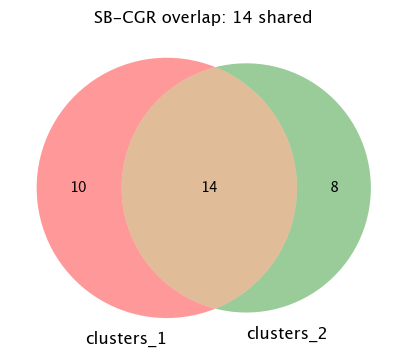

In [22]:
plot_sb_cgr_cluster_venn(clusters_1, clusters_2)


In [23]:
unique_cluster_ids_1 = cluster_overlap["unique_cluster_ids_1"]
overlap_cluster_ids = cluster_overlap["overlap_cluster_ids"]
unique_cluster_ids_2 = cluster_overlap["unique_cluster_ids_2"]

print(f"Unique clusters in set 1: {unique_cluster_ids_1}")
print(f"Overlap clusters: {overlap_cluster_ids}")
print(f"Unique clusters in set 2: {unique_cluster_ids_2}")


Unique clusters in set 1: ['3.4', '4.3', '3.5', '3.6', '6.1', '6.2', '4.2', '5.1', '4.4', '3.1']
Overlap clusters: [('2.3', '2.3'), ('2.4', '2.4'), ('3.10', '3.11'), ('3.7', '3.8'), ('3.2', '3.2'), ('3.3', '3.4'), ('4.1', '4.1'), ('3.8', '3.9'), ('3.9', '3.10'), ('3.11', '3.12'), ('2.5', '2.6'), ('3.12', '3.13'), ('2.2', '2.2'), ('2.1', '2.1')]
Unique clusters in set 2: ['4.3', '3.1', '3.3', '3.5', '2.5', '3.6', '3.7', '4.2']


In [24]:
cluster_index = '2.1'
if cluster_index in clusters_1.keys():
    display(HTML(routes_clustering_report(tree_1, clusters_1, cluster_index,
                         unique_sb_cgrs_1)))
else:
    print(f"Cluster {cluster_index} not found in the clustering results.")


Target Molecule: C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
Group index: 2.1
Size of Cluster: 14 routes
Target Molecule Molecule Not In Stock Molecule In Stock
"Route 2730 — 6 steps, score=0.131"
Step 1: CO.[OH-].c1cc(ccn1)CNc2c(C#N)cccn2>>c1cc(ccn1)CNc2c(C(O)=O)cccn2Step 2: CO.c1cc(ccn1)CNc2c(C(O)=O)cccn2>>c1cc(ccn1)CNc2ncccc2C(=O)OCStep 3: CC(=O)OC(C)=O.c1cc(ccn1)CNc2ncccc2C(=O)OC>>c1cc(ccn1)CN(c2ncccc2C(=O)OC)C(=O)CStep 4: c1cc(ccn1)CN(c2ncccc2C(=O)OC)C(=O)C>>c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=OStep 5: c1cc(ccc1C2(CCCC2)C#N)N.c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=O>>C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#NStep 6: C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#N>>C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
"Route 2731 — 6 steps, score=0.131"
Step 1: CCO.[OH-].c1cc(ccn1)CNc2c(C#N)cccn2>>c1cc(ccn1)CNc2c(C(O)=O)cccn2Step 2: CO.c1cc(ccn1)CNc2c(C(O)=O)cccn2>>c1cc(ccn1)CNc2ncccc2C(=O)OCStep 3: CC(=O)OC(C)=O.c1cc(ccn1)CNc2ncccc2C(=O)OC>>c1cc(ccn1)CN(c2ncccc2C(=O)OC)C(=O)CStep 4: c1cc(ccn1)CN(c2ncccc2C(=O)OC)C(=O)C>>c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=OStep 5: c1cc(ccc1C2(CCCC2)C#N)N.c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=O>>C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#NStep 6: C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#N>>C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
"Route 2736 — 6 steps, score=0.131"
Step 1: C(O)CC.[OH-].c1cc(ccn1)CNc2c(C#N)cccn2>>c1cc(ccn1)CNc2c(C(O)=O)cccn2Step 2: CO.c1cc(ccn1)CNc2c(C(O)=O)cccn2>>c1cc(ccn1)CNc2ncccc2C(=O)OCStep 3: CC(=O)OC(C)=O.c1cc(ccn1)CNc2ncccc2C(=O)OC>>c1cc(ccn1)CN(c2ncccc2C(=O)OC)C(=O)CStep 4: c1cc(ccn1)CN(c2ncccc2C(=O)OC)C(=O)C>>c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=OStep 5: c1cc(ccc1C2(CCCC2)C#N)N.c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=O>>C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#NStep 6: C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#N>>C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
"Route 2738 — 6 steps, score=0.131"


In [25]:
cluster_index = '2.1'
if cluster_index in clusters_2.keys():
    display(HTML(routes_clustering_report(tree_2, clusters_2, cluster_index,
                         unique_sb_cgrs_2)))
else:
    print(f"Cluster {cluster_index} not found in the clustering results.")


Target Molecule: C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
Group index: 2.1
Size of Cluster: 21 routes
Target Molecule Molecule Not In Stock Molecule In Stock
"Route 1899 — 4 steps, score=0.157"
Step 1: CO.[OH-].c1cc(ccn1)CNc2c(C#N)cccn2>>c1cc(ccn1)CNc2c(C(O)=O)cccn2Step 2: CC(=O)OC(C)=O.c1cc(ccn1)CNc2c(C(O)=O)cccn2>>c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=OStep 3: c1cc(ccc1C2(CCCC2)C#N)N.c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=O>>C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#NStep 4: C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#N>>C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
"Route 1900 — 4 steps, score=0.157"
Step 1: CCO.[OH-].c1cc(ccn1)CNc2c(C#N)cccn2>>c1cc(ccn1)CNc2c(C(O)=O)cccn2Step 2: CC(=O)OC(C)=O.c1cc(ccn1)CNc2c(C(O)=O)cccn2>>c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=OStep 3: c1cc(ccc1C2(CCCC2)C#N)N.c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=O>>C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#NStep 4: C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#N>>C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
"Route 1905 — 4 steps, score=0.157"
Step 1: C(O)CC.[OH-].c1cc(ccn1)CNc2c(C#N)cccn2>>c1cc(ccn1)CNc2c(C(O)=O)cccn2Step 2: CC(=O)OC(C)=O.c1cc(ccn1)CNc2c(C(O)=O)cccn2>>c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=OStep 3: c1cc(ccc1C2(CCCC2)C#N)N.c1cc(ccn1)CN(c2c(cccn2)C(O)=O)C(C)=O>>C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#NStep 4: C1CCCC1(c2ccc(cc2)NC(c3c(N(C(=O)C)Cc4ccncc4)nccc3)=O)C#N>>C1CCCC1(c2ccc(cc2)NC(=O)c3c(NCc4ccncc4)nccc3)C#N
"Route 1907 — 4 steps, score=0.157"


In [26]:
cgr = all_route_cgrs_2[2949]
cgr.clean2d()
cgr

### blue-colored bond is transient bond (formed and removed during the synthesis)

### Check Whether Routes From the Same Tree Search Differ Only by Reaction Order

In [28]:
route_order_variant_groups = route_order_variant_sets(all_route_cgrs_1)
len(route_order_variant_groups)

49

In [29]:
y = 17
id_route_order_sens = route_order_variant_groups[y]
print(id_route_order_sens)
rr_id_1 = id_route_order_sens[0][0]
rr_id_2 = id_route_order_sens[1][0]

[[322], [1349]]


In [30]:
cgr_1 = all_route_cgrs_1[rr_id_1]
cgr_1.clean2d()
display(cgr_1)
cgr_2 = all_route_cgrs_1[rr_id_2]
cgr_2.clean2d()
display(cgr_2)

In [31]:
print(f"Route ID 1: {rr_id_1}")
display(SVG(get_route_svg(tree_1, rr_id_1)))
print(f"Route ID 2: {rr_id_2}")
display(SVG(get_route_svg(tree_1, rr_id_2)))

Route ID 1: 322


Route ID 2: 1349
